<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# Enhanced Version:
1. Class distribution visualized, class weights applied
2. StandardScaler - fit_transform only X_train, X_test only transform
3. CV changed to [5, 10]
4. Added models:
   1. Random Forest
   2. XGBoost
5. Added classification_report for XGBClassifier predictions
6. Added time measurement

# **Space X  Falcon 9 First Stage Landing Prediction**


## Hands on Lab: Complete the Machine Learning Prediction lab


Estimated time needed: **60** minutes


Space X advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because Space X can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against space X for a rocket launch.   In this lab, you will create a machine learning pipeline  to predict if the first stage will land given the data from the preceding labs.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planed. Space X; performs a controlled landing in the oceans.


## Objectives


Perform exploratory  Data Analysis and determine Training Labels

*   create a column for the class
*   Standardize the data
*   Split into training data and test data

\-Find best Hyperparameter for SVM, Classification Tree, Logistic Regression and K Nearest Neighbors

*   Find the method performs best using test data


## Import Libraries and Define Auxiliary Functions


In [1]:
# SB
# !pip install numpy
# !pip install pandas
# !pip install seaborn
# !pip install scikit-learn

We will import the following libraries for the lab


In [245]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV, StratifiedKFold
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier
# Random Forest classification algorithm
from sklearn.ensemble import RandomForestClassifier
# XGBoost classification algorithm
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

This function is to plot the confusion matrix.


In [176]:
def plot_confusion_matrix(y,y_predict, cv):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    # ax= plt.subplot()  # SB: eliminated
    ax= plt.gca()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'+' CV='+cv) 
    ax.xaxis.set_ticklabels(['did not land', 'landed'])
    ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    # plt.show()  SB: eliminated

## Load the dataframe


Load the data


In [4]:
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

In [43]:
display(data.head())

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


Text(0.5, 1.0, 'Class Distribution')

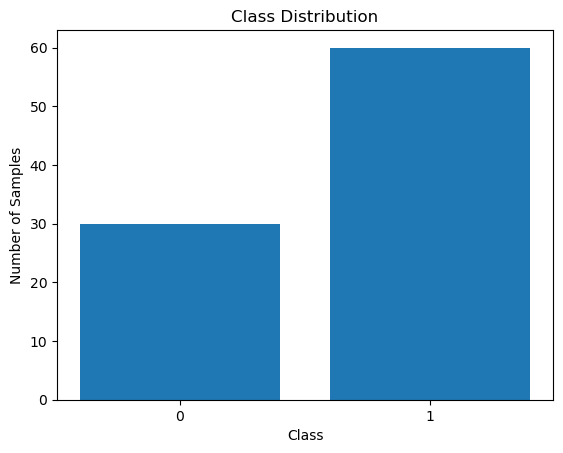

In [61]:
counts = data['Class'].value_counts().sort_index(ascending=True)

plt.bar(counts.index, counts)
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks([0, 1], ['0', '1'])
plt.title('Class Distribution')

In [62]:
X = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')

In [63]:
X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
88,89.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


## TASK  1


Create a NumPy array from the column <code>Class</code> in <code>data</code>, by applying the method <code>to_numpy()</code>  then
assign it  to the variable <code>Y</code>,make sure the output is a  Pandas series (only one bracket df\['name of  column']).


In [64]:
Y = data['Class'].to_numpy()

## TASK  2


Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.


In [65]:
# # students get this
# # SB: standardization moved after train test split
# transform = preprocessing.StandardScaler()

# X = transform.fit_transform(X) # SB: scale data (fit_transform X => data leakeage =>> fit_transform X_train, transform X_test)

We split the data into training and testing data using the  function  <code>train_test_split</code>.   The training data is divided into validation data, a second set used for training  data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.


## TASK  3


Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to  0.2 and random_state to 2. The training data and test data should be assigned to the following labels.


<code>X_train, X_test, Y_train, Y_test</code>


In [66]:
# Train test split with stratification since Class is imbalanced
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2, shuffle=True, stratify=Y)

In [67]:
# students get this
transform = preprocessing.StandardScaler()

X_train = transform.fit_transform(X_train) # SB: scale and transform training data
X_test = transform.transform(X_test) # SB: transform test data

we can see we only have 18 test samples.


In [68]:
Y_test.shape

(18,)

## TASK  4


Create a logistic regression object  then create a  GridSearchCV object  <code>logreg_cv</code> with cv = [5, 10].  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [169]:
# CV option settings (applied to all models)
cvs = [5, 10]
cv_options = [StratifiedKFold(n_splits=cv, shuffle=True, random_state=42) for cv in cvs]

In [164]:
# SB: Logistic Regression with class weights
parameters = {
    "C":[0.01, 0.1, 1],
    'penalty':['l2'],  # l1 lasso l2 ridge
    'solver':['lbfgs'],
    'class_weight': ['balanced', None],
}

lr = LogisticRegression()  # Logistic regression object
model_dict={}

for cv in cv_options:
    logreg_cv = GridSearchCV(estimator=lr, param_grid=parameters, cv=cv, verbose=1)
    logreg_cv.fit(X_train, Y_train)
    
    key=cv.n_splits
    model_dict[key]=logreg_cv

    print(f"\nResults for folds = {key}")
    print("tuned hyperparameters (best parameters): ", model_dict[key].best_params_)
    print("accuracy: ", model_dict[key].best_score_, "\n\n")

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Results for folds = 5
tuned hyperparameters (best parameters):  {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy:  0.8761904761904763 


Fitting 10 folds for each of 6 candidates, totalling 60 fits

Results for folds = 10
tuned hyperparameters (best parameters):  {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy:  0.8767857142857143 




We output the <code>GridSearchCV</code> object for logistic regression. We display the best parameters using the data attribute <code>best_params\_</code> and the accuracy on the validation data using the data attribute <code>best_score\_</code>.


In [165]:
# print("tuned hyperparameters (best parameters): ",logreg_cv.best_params_)
# print("accuracy: ",logreg_cv.best_score_)

## TASK  5


Calculate the accuracy on the test data using the method <code>score</code>:


In [166]:
for key in model_dict.keys():
    print(f"Key = {key}: Score: {model_dict[key].score(X_test, Y_test)}")

Key = 5: Score: 0.7777777777777778
Key = 10: Score: 0.7777777777777778


Lets look at the confusion matrices:


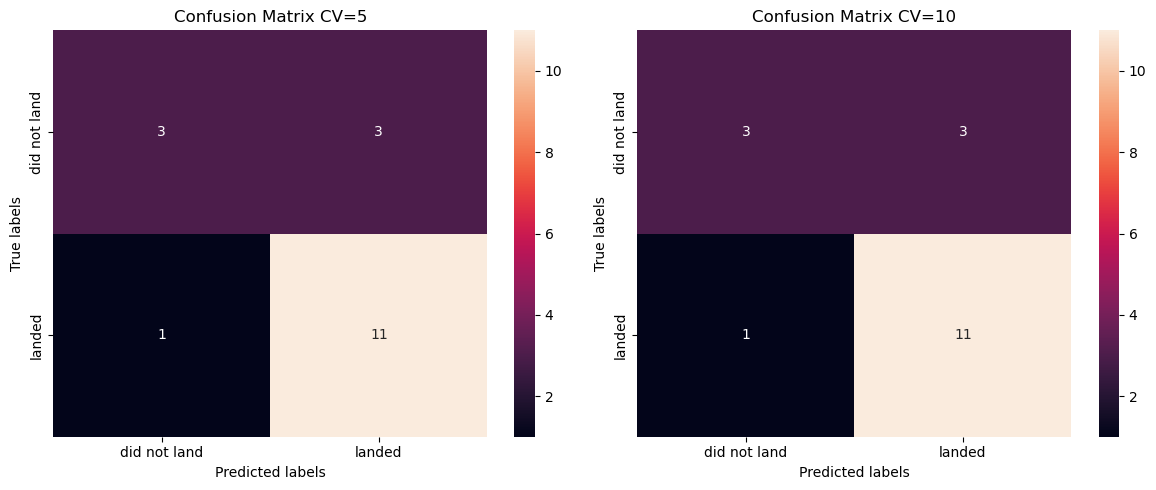

In [167]:
# Create a dict with yhats
yhat_dict={key: model.predict(X_test) for key, model in model_dict.items()}

# Create axes to plot side by side
fig, axes = plt.subplots(1, len(yhat_dict), figsize=(12,5))

# Plot confusion matrices
for key, ax in zip(yhat_dict.keys(), axes):
    plt.sca(ax)
    plot_confusion_matrix(Y_test, yhat_dict[key], str(key))

plt.tight_layout()
plt.show()

Examining the confusion matrix, we see that logistic regression can distinguish between the different classes.  We see that the problem is false positives.  
Adding class_weight balanced option improved training score, but degraded the test score <=> overfitting.  

Overview (transition from the course version):

True Positive - 12 => 11 (True label is landed, Predicted label is also landed)  
False Positive - 3 (True label is not landed, Predicted label is landed)  
False Negative - 0 => 1


## TASK  6


Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = [5, 10].  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [170]:
parameters = {
    'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
    'C': np.logspace(-3, 3, 5),
    'gamma': np.logspace(-3, 3, 5),
    'class_weight': ['balanced', None]
}

svm = SVC() # Support Vector Machine classifier object
model_dict={}

for cv in cv_options:
    svm_cv = GridSearchCV(estimator=svm, param_grid=parameters, cv=cv, verbose=1)
    svm_cv.fit(X_train, Y_train)
    
    key=cv.n_splits
    model_dict[key]=svm_cv

    print(f"\nResults for folds = {key}")
    print("tuned hyperparameters (best parameters): ", model_dict[key].best_params_)
    print("accuracy: ", model_dict[key].best_score_, "\n\n")

Fitting 5 folds for each of 250 candidates, totalling 1250 fits

Results for folds = 5
tuned hyperparameters (best parameters):  {'C': 1.0, 'class_weight': 'balanced', 'gamma': 0.001, 'kernel': 'rbf'}
accuracy:  0.8761904761904763 


Fitting 10 folds for each of 250 candidates, totalling 2500 fits

Results for folds = 10
tuned hyperparameters (best parameters):  {'C': 0.03162277660168379, 'class_weight': 'balanced', 'gamma': 1.0, 'kernel': 'sigmoid'}
accuracy:  0.8785714285714284 




## TASK  7


Calculate the accuracy on the test data using the method <code>score</code>:


In [171]:
for key in model_dict.keys():
    print(f"Key = {key}: Score: {model_dict[key].score(X_test, Y_test)}")

Key = 5: Score: 0.8333333333333334
Key = 10: Score: 0.7777777777777778


We can plot the confusion matrix


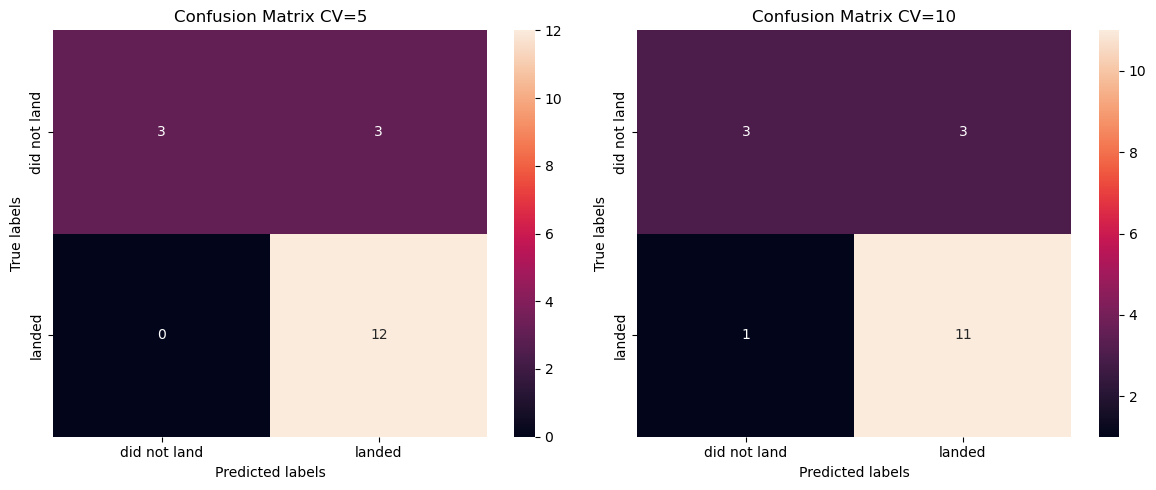

In [177]:
# Create a dict with yhats
yhat_dict={key: model.predict(X_test) for key, model in model_dict.items()}

# Create axes to plot side by side
fig, axes = plt.subplots(1, len(yhat_dict), figsize=(12,5))

# Plot confusion matrices
for key, ax in zip(yhat_dict.keys(), axes):
    plt.sca(ax)
    plot_confusion_matrix(Y_test,yhat_dict[key], str(key))

plt.tight_layout()
plt.show()

Test results for CV = 10 the same as for logistic regression.
SVM CV = 5, slightly better.

Overview (CV 5 / 10):  
True Positive - 12 / 11 (True label is landed, Predicted label is also landed)  
False Positive - 3 (True label is not landed, Predicted label is landed)  
False Negative - 0 / 1

## TASK  8


Create a decision tree classifier object then  create a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [179]:
parameters = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [2*n for n in range(1,10)],
    'max_features': [None, 'sqrt'],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None]
}

tree = DecisionTreeClassifier()  # Decision Tree classifier object
model_dict={}

for cv in cv_options:
    tree_cv = GridSearchCV(estimator=tree, param_grid=parameters, cv=cv, verbose=1)
    tree_cv.fit(X_train, Y_train)
    
    key=cv.n_splits
    model_dict[key]=tree_cv

    print(f"\nResults for folds = {key}")
    print("tuned hyperparameters (best parameters): ", model_dict[key].best_params_)
    print("accuracy: ", model_dict[key].best_score_, "\n\n")

Fitting 5 folds for each of 1296 candidates, totalling 6480 fits

Results for folds = 5
tuned hyperparameters (best parameters):  {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'splitter': 'best'}
accuracy:  0.9314285714285713 


Fitting 10 folds for each of 1296 candidates, totalling 12960 fits

Results for folds = 10
tuned hyperparameters (best parameters):  {'class_weight': None, 'criterion': 'gini', 'max_depth': 14, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'splitter': 'best'}
accuracy:  0.9053571428571429 




## TASK  9


Calculate the accuracy of tree_cv on the test data using the method <code>score</code>:


In [181]:
for key in model_dict.keys():
    print(f"Key = {key}: Score: {model_dict[key].score(X_test, Y_test)}")

Key = 5: Score: 0.7222222222222222
Key = 10: Score: 0.7777777777777778


We can plot the confusion matrix


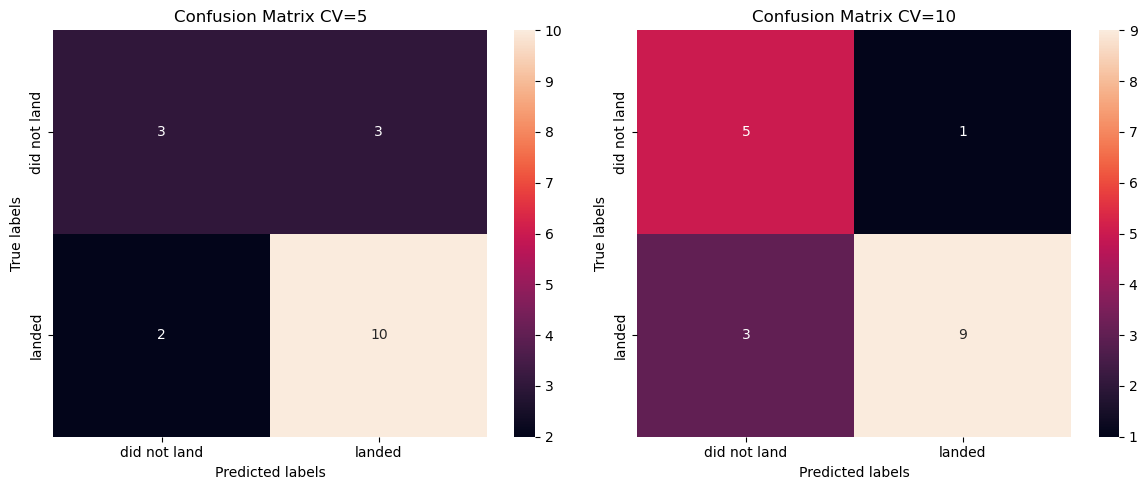

In [182]:
# Create a dict with yhats
yhat_dict={key: model.predict(X_test) for key, model in model_dict.items()}

# Create axes to plot side by side
fig, axes = plt.subplots(1, len(yhat_dict), figsize=(12,5))

# Plot confusion matrices
for key, ax in zip(yhat_dict.keys(), axes):
    plt.sca(ax)
    plot_confusion_matrix(Y_test,yhat_dict[key], str(key))

plt.tight_layout()
plt.show()

## TASK  10


Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [187]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'weights': ['uniform', 'distance'],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()  # K Nearest Neighbors classifier object
model_dict={}

for cv in cv_options:
    KNN_cv = GridSearchCV(estimator=KNN, param_grid=parameters, cv=cv, verbose=1)
    KNN_cv.fit(X_train, Y_train)
    
    key=cv.n_splits
    model_dict[key]=KNN_cv

    print(f"\nResults for folds = {key}")
    print("tuned hyperparameters (best parameters): ", model_dict[key].best_params_)
    print("accuracy: ", model_dict[key].best_score_, "\n\n")

Fitting 5 folds for each of 160 candidates, totalling 800 fits

Results for folds = 5
tuned hyperparameters (best parameters):  {'algorithm': 'auto', 'n_neighbors': 8, 'p': 1, 'weights': 'uniform'}
accuracy:  0.8619047619047618 


Fitting 10 folds for each of 160 candidates, totalling 1600 fits

Results for folds = 10
tuned hyperparameters (best parameters):  {'algorithm': 'auto', 'n_neighbors': 8, 'p': 1, 'weights': 'uniform'}
accuracy:  0.8767857142857143 




## TASK  11


Calculate the accuracy of knn_cv on the test data using the method <code>score</code>:


In [188]:
for key in model_dict.keys():
    print(f"Key = {key}: Score: {model_dict[key].score(X_test, Y_test)}")

Key = 5: Score: 0.8333333333333334
Key = 10: Score: 0.8333333333333334


We can plot the confusion matrix


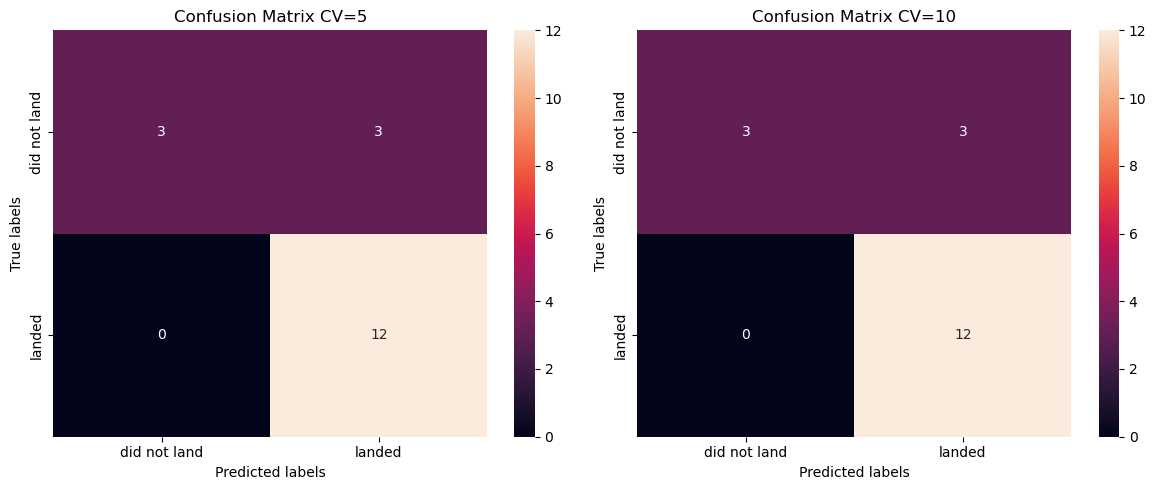

In [189]:
# Create a dict with yhats
yhat_dict={key: model.predict(X_test) for key, model in model_dict.items()}

# Create axes to plot side by side
fig, axes = plt.subplots(1, len(yhat_dict), figsize=(12,5))

# Plot confusion matrices
for key, ax in zip(yhat_dict.keys(), axes):
    plt.sca(ax)
    plot_confusion_matrix(Y_test,yhat_dict[key], str(key))

plt.tight_layout()
plt.show()

## TASK  12


Find the method performs best:


## Summary

After removing leakage from train test split, applying class_weight where available and applying shuffle=True to StraitifiedKFold,  
KNN improved significantly (with both 5 and 10 folds) compared to other models.
On the other Log

| Model                    | Train Accuracy | Test Accuracy |
|:----------------------   |---------------:|--------------:|
| K Nearest Neigbors      5|          86.2% |         83.3% |
| Support Vector Machine  5|          87.6% |         83.3% |
| K Nearest Neigbors     10|          87.7% |         83.3% |
| Logistic Regression     5|          87.6% |         77.8% |
| Logistic Regression    10|          87.7% |         77.8% |
| Support Vector Machine 10|          87.9% |         77.8% |
| Decision Tree          10|          90.5% |         77.8% |
| Decision Tree           5|          93.1% |         72.2% |

## TASK  13 - SB
Create and evaluate random forest model

In [226]:
# SB: keeping the same parameters (where possible) as for the decission tree
parameters = {
    'n_estimators': [10, 50, 100, 200],
    'criterion': ['gini', 'entropy'],
    'max_depth': [2*n for n in range(1,10)],
    'max_features': [None, 'sqrt'],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}

forest = RandomForestClassifier(random_state=42)
model_dict={}

for cv in cv_options:
    forest_cv = GridSearchCV(estimator=forest, param_grid=parameters, n_jobs=-1, cv=cv)

    # Fit with time measurement
    time_start=time.time()
    forest_cv.fit(X_train, Y_train)
    time_end=time.time()

    min_elapsed=int((time_end-time_start)//60)
    sec_elapsed=(time_end-time_start)%60
    
    key=cv.n_splits
    model_dict[key]=forest_cv

    print(f"\nResults for folds = {key}")
    print(f"Elapsed time: {time_end-time_start}")
    print(f"Elapsed time: {min_elapsed}:{sec_elapsed:.3f}")
    print("tuned hyperparameters (best parameters): ", model_dict[key].best_params_)
    print("accuracy: ", model_dict[key].best_score_, "\n\n")


Results for folds = 5
Elapsed time: 120.13698077201843
Elapsed time: 2:0.137
tuned hyperparameters (best parameters):  {'criterion': 'gini', 'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 10}
accuracy:  0.9028571428571428 



Results for folds = 10
Elapsed time: 265.42910718917847
Elapsed time: 4:25.429
tuned hyperparameters (best parameters):  {'criterion': 'gini', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}
accuracy:  0.9035714285714287 




In [228]:
# SB: parameter grid adjusted
parameters = {
    'n_estimators': [1, 2, 3, 4, 5, 10, 20, 30, 40, 50],
    'criterion': ['gini', 'entropy'],
    'max_depth': [n for n in range(3,7)],
    'max_features': [None, 'sqrt'],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}

forest = RandomForestClassifier(random_state=42)
model_dict={}

for cv in cv_options:
    forest_cv = GridSearchCV(estimator=forest, param_grid=parameters, n_jobs=-1, cv=cv)

    # Fit with time measurement
    time_start=time.time()
    forest_cv.fit(X_train, Y_train)
    time_end=time.time()

    min_elapsed=int((time_end-time_start)//60)
    sec_elapsed=(time_end-time_start)%60
    
    key=cv.n_splits
    model_dict[key]=forest_cv

    print(f"\nResults for folds = {key}")
    print(f"Elapsed time: {time_end-time_start}")
    print(f"Elapsed time: {min_elapsed}:{sec_elapsed:.3f}")
    print("tuned hyperparameters (best parameters): ", model_dict[key].best_params_)
    print("accuracy: ", model_dict[key].best_score_, "\n\n")


Results for folds = 5
Elapsed time: 26.441120147705078
Elapsed time: 0:26.441
tuned hyperparameters (best parameters):  {'criterion': 'gini', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 5}
accuracy:  0.9038095238095238 



Results for folds = 10
Elapsed time: 56.26160144805908
Elapsed time: 0:56.262
tuned hyperparameters (best parameters):  {'criterion': 'gini', 'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 5}
accuracy:  0.9053571428571429 




Calculate the accuracy of forest_cv on the test data using the method <code>score</code>:


In [229]:
for key in model_dict.keys():
    print(f"Key = {key}: Score: {model_dict[key].score(X_test, Y_test)}")

Key = 5: Score: 0.7777777777777778
Key = 10: Score: 0.7777777777777778


We can plot the confusion matrix


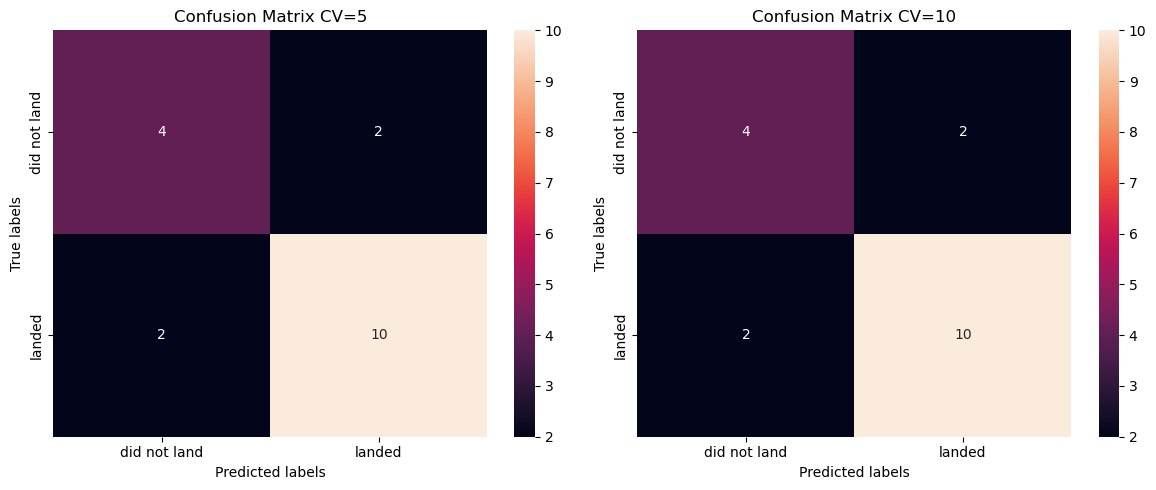

In [230]:
# Create a dict with yhats
yhat_dict={key: model.predict(X_test) for key, model in model_dict.items()}

# Create axes to plot side by side
fig, axes = plt.subplots(1, len(yhat_dict), figsize=(12,5))

# Plot confusion matrices
for key, ax in zip(yhat_dict.keys(), axes):
    plt.sca(ax)
    plot_confusion_matrix(Y_test,yhat_dict[key], str(key))

plt.tight_layout()
plt.show()

## TASK  14 - SB
Create and evaluate XGBoost model

In [242]:
parameters = {
    'n_estimators': [10, 50, 100, 200],
    'max_depth': np.arange(3,7),
    'max_leaves': [0, 4, 8, 16],
    'grow_policy': ['depthwise', 'lossguide'],
    'learning_rate': np.linspace(0.01, 1, 10),
    'booster': ['gbtree', 'gblinear', 'dart']
}

xgb = XGBClassifier(tree_method='approx', random_state=42)
model_dict={}

for cv in cv_options:
    xgb_cv = GridSearchCV(estimator=xgb, param_grid=parameters, n_jobs=-1, cv=cv)

    # Fit with time measurement
    time_start=time.time()
    xgb_cv.fit(X_train, Y_train)
    time_end=time.time()

    min_elapsed=int((time_end-time_start)//60)
    sec_elapsed=(time_end-time_start)%60
    
    key=cv.n_splits
    model_dict[key]=xgb_cv

    print(f"\nResults for folds = {key}")
    print(f"Elapsed time: {min_elapsed}:{sec_elapsed:.3f}")
    print("tuned hyperparameters (best parameters): ", model_dict[key].best_params_)
    print("accuracy: ", model_dict[key].best_score_, "\n")


Results for folds = 5
Elapsed time: 3:0.557
tuned hyperparameters (best parameters):  {'booster': 'gbtree', 'grow_policy': 'depthwise', 'learning_rate': 0.89, 'max_depth': 3, 'max_leaves': 4, 'n_estimators': 10}
accuracy:  0.8761904761904763 


Results for folds = 10
Elapsed time: 6:39.470
tuned hyperparameters (best parameters):  {'booster': 'gbtree', 'grow_policy': 'depthwise', 'learning_rate': 0.34, 'max_depth': 3, 'max_leaves': 0, 'n_estimators': 50}
accuracy:  0.8767857142857143 



Calculate the accuracy of xgb_cv on the test data using the method <code>score</code>:


In [243]:
for key in model_dict.keys():
    print(f"Key = {key}: Score: {model_dict[key].score(X_test, Y_test)}")

Key = 5: Score: 0.8888888888888888
Key = 10: Score: 0.7777777777777778


We can plot the confusion matrix


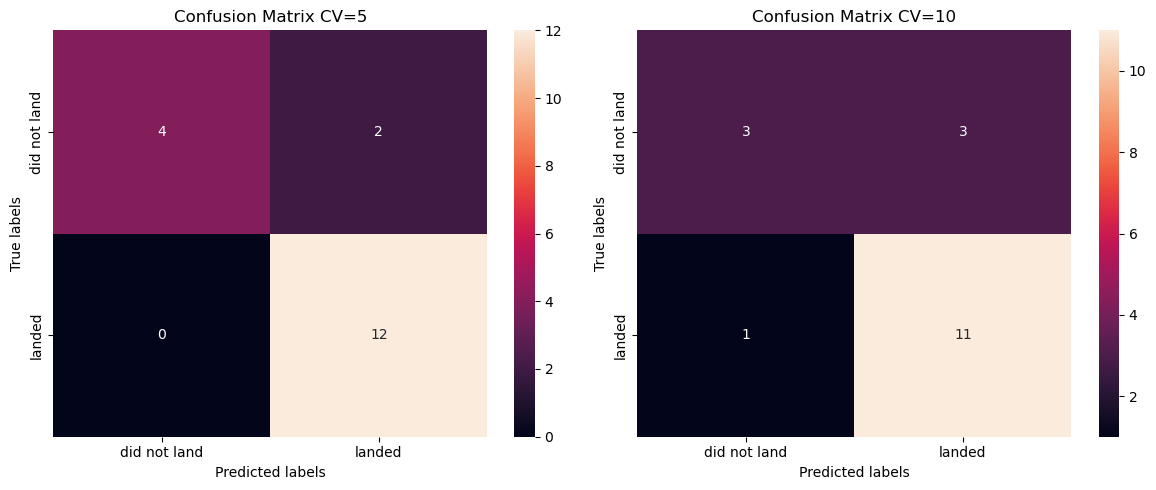

In [244]:
# Create a dict with yhats
yhat_dict={key: model.predict(X_test) for key, model in model_dict.items()}

# Create axes to plot side by side
fig, axes = plt.subplots(1, len(yhat_dict), figsize=(12,5))

# Plot confusion matrices
for key, ax in zip(yhat_dict.keys(), axes):
    plt.sca(ax)
    plot_confusion_matrix(Y_test,yhat_dict[key], str(key))

plt.tight_layout()
plt.show()

In [260]:
# Classification reports
for key in yhat_dict.keys():
    print(f"Classification report for folds = {key}\n")
    print(classification_report(Y_test, yhat_dict[key]), "\n\n")

Classification report for folds = 5

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         6
           1       0.86      1.00      0.92        12

    accuracy                           0.89        18
   macro avg       0.93      0.83      0.86        18
weighted avg       0.90      0.89      0.88        18
 


Classification report for folds = 10

              precision    recall  f1-score   support

           0       0.75      0.50      0.60         6
           1       0.79      0.92      0.85        12

    accuracy                           0.78        18
   macro avg       0.77      0.71      0.72        18
weighted avg       0.77      0.78      0.76        18
 




### XGBoostClassifier Summary:
The model with hyperparameters tuned with 5 folds shows the best results in terms of:
* Accuracy: 88.9%
* False Negative Rate: 0,0%
* False Positive rate: 33.3% (False Positives being the issue)


## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log--!>


<!--| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|--!>


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
